In [10]:
# import packages
import numpy as np
import pandas as pd
import seaborn as sb
import glob 

import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-pastel')

Step 1: merge all the participant files from 1C

In [11]:
folder_path = "dfs_per_participant"
files = glob.glob(f"{folder_path}/*csv") #get name of all files in folder

dataframes = [] #list of all dataframes
for file in files:
    print('loading:', file)
    df = pd.read_csv(file)
    dataframes.append(df)
full_df = pd.concat(dataframes, ignore_index=True) #merge the dataframes


loading: dfs_per_participant\df_AS14.01.csv
loading: dfs_per_participant\df_AS14.02.csv
loading: dfs_per_participant\df_AS14.03.csv
loading: dfs_per_participant\df_AS14.05.csv
loading: dfs_per_participant\df_AS14.06.csv
loading: dfs_per_participant\df_AS14.07.csv
loading: dfs_per_participant\df_AS14.12.csv
loading: dfs_per_participant\df_AS14.13.csv
loading: dfs_per_participant\df_AS14.14.csv
loading: dfs_per_participant\df_AS14.15.csv
loading: dfs_per_participant\df_AS14.16.csv
loading: dfs_per_participant\df_AS14.19.csv
loading: dfs_per_participant\df_AS14.23.csv
loading: dfs_per_participant\df_AS14.24.csv
loading: dfs_per_participant\df_AS14.25.csv
loading: dfs_per_participant\df_AS14.27.csv
loading: dfs_per_participant\df_AS14.28.csv
loading: dfs_per_participant\df_AS14.29.csv
loading: dfs_per_participant\df_AS14.30.csv
loading: dfs_per_participant\df_AS14.32.csv
loading: dfs_per_participant\df_AS14.33.csv


Step 2; create a classifications target

first attempt:
for avg_mood_target
•  low: mood < 5 
•  medium: 5 ≤ mood < 7 
•  high: mood ≥ 7
This is thus for the average mood over that timespan

second attempt:
Due to strong class imbalance when using fixed thresholds, we applied a quantile-based discretization to ensure balanced class distributions, improving the reliability of the classification models. groups aren’t perfectly equal because qcut can’t split identical values and must keep them together. cutoff values can be seen from the classification action. Low:2.999 - 6.8 < medium: 6.8 - 7.4 < high: 7.4 - 9.333.



In [12]:
full_df["mood_class"] = pd.qcut(full_df["avg_mood_target"], q=3, labels=["low", "medium", "high"]) #split the mood values into 3 equally sized groups and label them low, medium, high basef on the avg_mood_target values.
cutoff_values = pd.qcut(full_df["avg_mood_target"], q=3) #gets the cutoff values
full_df.to_csv('random forest datasets/dataset_classification.csv', index=False)
full_df["mood_class"].value_counts()
#full_df.groupby("mood_class")["id"].nunique()
#full_df.groupby(["id", "mood_class"]).size().unstack(fill_value=0)

mood_class
low       313
medium    289
high      239
Name: count, dtype: int64

Step 3; split train/test set in a time-aware way
Since our rows are sequential windows per patient, the split should respect time and avoid training on future rows while testing on earlier ones. What “time-aware split” means here. For each participant separately: take the earlier rows for training, take the later rows for testing. Then do that for every participant, and combine all participant-level train parts into one training set and all test parts into one test set.

In [13]:
train_parts = [] #early data
test_parts = [] #later data
split_value = 0.8

for partcipant_id, group in full_df.groupby('id'):  #split dataset into groups based on id
    group = group.sort_values('target_day') #sort by target day
    split_idx = int(len(group) * split_value) #decide where to split
    
    train_group = group.iloc[:split_idx]
    test_group = group.iloc[split_idx:]

    train_parts.append(train_group)
    test_parts.append(test_group)

train_df = pd.concat(train_parts, ignore_index=True)
test_df = pd.concat(test_parts, ignore_index=True)

step 4; removing target leakage columns.
Target leakage = giving the model information it should not have at prediction time. As we try to predict next-day mood, the model should only see information from the past (window). Not anything from the target day. therefore we remove the target features from the dataframe, so we remove avg_mood_target, std_mood_target, trend_mood_target from the features. Additionally we remove id, t, and target_day as features.

In [14]:
cols_to_drop = [
    "mood_class",          # target
    "avg_mood_target",     # leakage
    "std_mood_target",     # leakage
    "trend_mood_target",   # leakage
    "id",                  # not a feature
    "t",                   # not useful
    "target_day"           # future info
]

X_train = train_df.drop(columns=cols_to_drop) #training features
y_train = train_df["mood_class"]

X_test = test_df.drop(columns=cols_to_drop) #same as training features
y_test = test_df["mood_class"]


Train a first random forest:


In [15]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42) #to make the results reproducible
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

make predictions

In [16]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = rf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred)) #gives the overall percentage of correct predictions
print(classification_report(y_test, y_pred)) #gives more detail for each class
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.536723163841808
              precision    recall  f1-score   support

        high       0.64      0.47      0.54        59
         low       0.55      0.71      0.62        59
      medium       0.45      0.42      0.43        59

    accuracy                           0.54       177
   macro avg       0.54      0.54      0.53       177
weighted avg       0.54      0.54      0.53       177

[[28 11 20]
 [ 6 42 11]
 [10 24 25]]


hyperparameter tuning using gridsearch with cross-validation via F1 

In [17]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {"n_estimators": [100, 200], "max_depth": [5, 10, None],}

rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3, #Use 3-fold cross-validation
    scoring="f1_weighted",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
print(grid_search.best_params_)
print(grid_search.best_score_)

{'max_depth': 10, 'n_estimators': 100}
0.37265303277791667


In [34]:
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred, labels = ['low', 'medium', 'high'])
print(cm)

Accuracy: 0.5875706214689266
              precision    recall  f1-score   support

        high       0.72      0.53      0.61        59
         low       0.59      0.68      0.63        59
      medium       0.50      0.56      0.53        59

    accuracy                           0.59       177
   macro avg       0.60      0.59      0.59       177
weighted avg       0.60      0.59      0.59       177

[[40 15  4]
 [18 33  8]
 [10 18 31]]


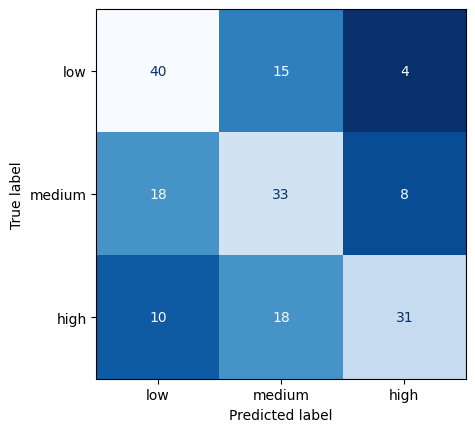

In [36]:
import matplotlib as plt
from sklearn.metrics import ConfusionMatrixDisplay

cmap = "Blues_r"
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels = ['low', 'medium', 'high'])
disp.plot(cmap = cmap, colorbar = False)
